# Introducción al Machine Learning con regresión lineal simple

## Problema: predecir el rendimiento de combustible de un automóvil

**Autor:** Dr. Mitchell Ángel Gómez Ortega  
**Fecha:** 28/06/2026

En este cuaderno construiremos un primer modelo de aprendizaje automático con
Scikit-learn utilizando el conjunto real **Auto MPG** de UCI.

La pregunta será:

> ¿Podemos estimar el rendimiento de combustible de un automóvil conociendo únicamente su peso?

## Objetivos

Al finalizar, el estudiante podrá:

1. Identificar un problema de regresión.
2. Diferenciar una variable de entrada y una variable objetivo.
3. Comprender la ecuación \(\hat y=mx+b\).
4. Separar datos de entrenamiento y prueba.
5. Entrenar `LinearRegression`.
6. Realizar predicciones.
7. Interpretar MAE, MSE, RMSE y \(R^2\).
8. Analizar residuos.

# 1. Contexto conceptual

```text
Inteligencia Artificial
        ↓
Machine Learning
        ↓
Aprendizaje supervisado
        ↓
Regresión
        ↓
Regresión lineal simple
```

En aprendizaje supervisado, cada ejemplo contiene entradas y un resultado
conocido. En este problema:

$$
X=\text{weight}
$$

$$
y=\text{mpg}
$$

`weight` representa el peso del automóvil en libras y `mpg` significa millas
recorridas por galón.

# 2. ¿Qué es la regresión lineal?

La regresión se utiliza cuando queremos predecir una **cantidad numérica continua**.

La regresión lineal simple utiliza la siguiente ecuación:

$$
\hat{y}=mx+b
$$

donde:

* $x$: variable de entrada;
* $y$: valor real;
* $\hat{y}$: valor predicho;
* $m$: pendiente de la recta;
* $b$: intersección con el eje vertical.

El residuo o error de una observación se calcula como:

$$
e=y-\hat{y}
$$

Scikit-learn calcula los valores de $m$ y $b$ que minimizan la suma de los errores cuadrados:

$$
\sum_{i=1}^{n}\left(y_i-\hat{y}_i\right)^2
$$


### Código explicado: Importación de bibliotecas

`Path` gestiona rutas, `urlretrieve` descarga los datos, Pandas organiza la
tabla, Matplotlib crea gráficas y Scikit-learn aporta el modelo y las métricas.

#### Código que se ejecutará

```python
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [7]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

# 3. Conjunto Auto MPG de UCI

El archivo contiene información de automóviles:

| Variable | Descripción |
|---|---|
| `mpg` | Millas por galón |
| `cylinders` | Cilindros |
| `displacement` | Desplazamiento |
| `horsepower` | Potencia |
| `weight` | Peso en libras |
| `acceleration` | Aceleración |
| `model_year` | Año del modelo |
| `origin` | Origen |
| `car_name` | Nombre |

En esta primera práctica solo utilizaremos `weight` y `mpg`.

## Estructura esperada

El repositorio debe conservar esta organización:

```text
scikitlearn/
├── Dataset/
│   └── Auto_MPG/
│       ├── auto-mpg.data
│       └── auto_mpg.csv
└── Regresión Lineal/
    └── 01_Regresion_Lineal_Simple_Auto_MPG_UCI.ipynb
```

El notebook debe ejecutarse desde la carpeta `Regresión Lineal`.

Durante la primera ejecución se creará automáticamente la carpeta
`Dataset/Auto_MPG`, se descargará el archivo original desde UCI y se generará
`auto_mpg.csv`. En las siguientes ejecuciones se utilizará la copia local.

### Código explicado: definición de rutas

- `Path.cwd()` obtiene la carpeta desde la cual se ejecuta el notebook.
- El notebook debe ejecutarse desde `Regresión Lineal`.
- `.parent` permite subir a la raíz del proyecto `scikitlearn`.
- La base se guardará dentro de `Dataset/Auto_MPG`.
- `mkdir()` crea la carpeta cuando todavía no existe.
- El archivo original se llamará `auto-mpg.data`.
- La copia en formato CSV se llamará `auto_mpg.csv`.

#### Código que se ejecutará

```python
notebook_directory = Path.cwd()
project_root = notebook_directory.parent

dataset_directory = (
    project_root
    / "Dataset"
    / "Auto_MPG"
)

raw_path = (
    dataset_directory
    / "auto-mpg.data"
)

csv_path = (
    dataset_directory
    / "auto_mpg.csv"
)

dataset_directory.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Carpeta del notebook:",
    notebook_directory.resolve(),
)

print(
    "Carpeta del conjunto de datos:",
    dataset_directory.resolve(),
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.


In [8]:
notebook_directory = Path.cwd()
project_root = notebook_directory.parent

dataset_directory = (
    project_root
    / "Dataset"
    / "Auto_MPG"
)

raw_path = (
    dataset_directory
    / "auto-mpg.data"
)

csv_path = (
    dataset_directory
    / "auto_mpg.csv"
)

dataset_directory.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Carpeta del notebook:",
    notebook_directory.resolve(),
)

print(
    "Carpeta del conjunto de datos:",
    dataset_directory.resolve(),
)

Carpeta del notebook: C:\Users\Mitch\PycharmProjects\scikitlearn\Regresión Lineal
Carpeta del conjunto de datos: C:\Users\Mitch\PycharmProjects\scikitlearn\Dataset\Auto_MPG


### Código explicado: descarga y carga del conjunto

- Primero se comprueba si existe `Dataset/Auto_MPG/auto_mpg.csv`.
- Si el CSV ya existe, se utiliza directamente.
- Si no existe, se descarga el archivo original desde UCI.
- El archivo original se guarda como `Dataset/Auto_MPG/auto-mpg.data`.
- Los nombres de las columnas se agregan porque el archivo original no contiene encabezado.
- El símbolo `?` se interpreta como un valor faltante.
- `engine="c"` permite respetar los nombres de automóviles escritos entre comillas.
- Finalmente, se crea `Dataset/Auto_MPG/auto_mpg.csv`.

#### Código que se ejecutará

```python
dataset_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/"
    "auto-mpg/auto-mpg.data"
)

columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name",
]

if csv_path.exists():
    data = pd.read_csv(csv_path)
    print("Se utilizó el archivo local.")
else:
    if not raw_path.exists():
        print("Descargando Auto MPG desde UCI...")
        urlretrieve(dataset_url, raw_path)

    data = pd.read_csv(
        raw_path,
        sep=r"\s+",
        names=columns,
        na_values="?",
        quotechar='"',
        engine="c",
    )

    data.to_csv(
        csv_path,
        index=False,
    )

    print("Se creó:", csv_path.resolve())

print("Registros:", len(data))
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.


In [9]:
dataset_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/"
    "auto-mpg/auto-mpg.data"
)

columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name",
]

if csv_path.exists():
    data = pd.read_csv(csv_path)
    print("Se utilizó el archivo local.")
else:
    if not raw_path.exists():
        print("Descargando Auto MPG desde UCI...")
        urlretrieve(dataset_url, raw_path)

    data = pd.read_csv(
        raw_path,
        sep=r"\s+",
        names=columns,
        na_values="?",
        quotechar='"',
        engine="c",
    )

    data.to_csv(
        csv_path,
        index=False,
    )

    print("Se creó:", csv_path.resolve())

print("Registros:", len(data))

Se utilizó el archivo local.
Registros: 398


# 4. Exploración de los datos

### Código explicado: Primeros registros

Cada fila representa un automóvil y cada columna una característica.

#### Código que se ejecutará

```python
data.head()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [10]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Código explicado: Dimensiones e información

`shape` muestra filas y columnas. `info()` permite revisar tipos y valores no nulos.

#### Código que se ejecutará

```python
print("Dimensiones:", data.shape)
data.info()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [11]:
print("Dimensiones:", data.shape)
data.info()

Dimensiones: (398, 9)
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


### Código explicado: Valores faltantes

El conjunto contiene valores faltantes en `horsepower`, pero las variables
`weight` y `mpg` utilizadas aquí están completas.

#### Código que se ejecutará

```python
data.isnull().sum()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [12]:
data.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

### Código explicado: Estadísticas de las variables seleccionadas

Se revisan media, desviación estándar, mínimo, máximo y cuartiles.

#### Código que se ejecutará

```python
selected_data = data[
    [
        "weight",
        "mpg",
    ]
].copy()

if selected_data.isnull().any().any():
    raise ValueError(
        "weight o mpg contienen valores faltantes."
    )

selected_data.describe()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [13]:
selected_data = data[
    [
        "weight",
        "mpg",
    ]
].copy()

if selected_data.isnull().any().any():
    raise ValueError(
        "weight o mpg contienen valores faltantes."
    )

selected_data.describe()

,weight,mpg
count,398.000000,398.000000
mean,2970.424623,23.514573
std,846.841774,7.815984
min,1613.000000,9.000000
25%,2223.750000,17.500000
50%,2803.500000,23.000000
75%,3608.000000,29.000000
max,5140.000000,46.600000


### Código explicado: Diagrama de dispersión

Cada punto es un automóvil. La tendencia descendente indica que los vehículos
más pesados suelen presentar menor rendimiento.

#### Código que se ejecutará

```python
plt.figure(figsize=(9, 6))

plt.scatter(
    selected_data["weight"],
    selected_data["mpg"],
    alpha=0.75,
)

plt.xlabel("Peso del automóvil (lb)")
plt.ylabel("Rendimiento (mpg)")
plt.title("Relación entre peso y rendimiento")
plt.grid(True)
plt.show()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

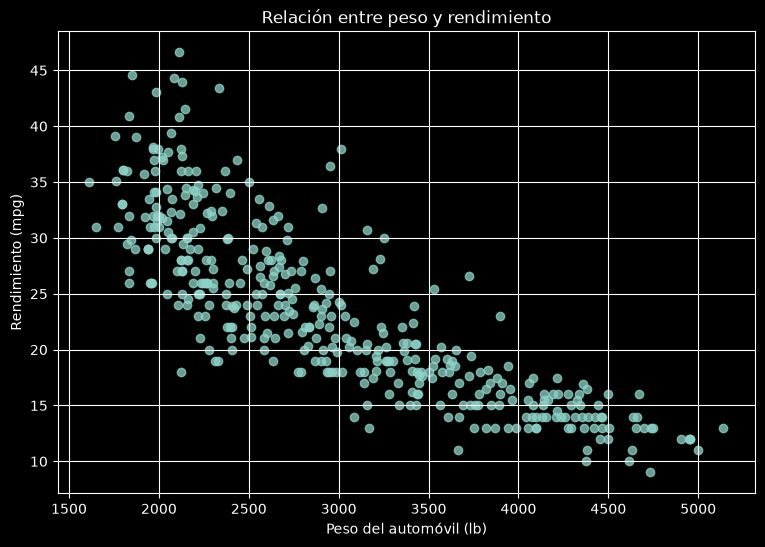

In [14]:
plt.figure(figsize=(9, 6))

plt.scatter(
    selected_data["weight"],
    selected_data["mpg"],
    alpha=0.75,
)

plt.xlabel("Peso del automóvil (lb)")
plt.ylabel("Rendimiento (mpg)")
plt.title("Relación entre peso y rendimiento")
plt.grid(True)
plt.show()

### Código explicado: Correlación

La correlación de Pearson se encuentra entre -1 y 1. Un valor negativo indica
que una variable disminuye cuando la otra aumenta.

#### Código que se ejecutará

```python
correlation = (
    selected_data
    .corr()
    .loc["weight", "mpg"]
)

print(
    f"Correlación weight-mpg: "
    f"{correlation:.4f}"
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [15]:
correlation = (
    selected_data
    .corr()
    .loc["weight", "mpg"]
)

print(
    f"Correlación weight-mpg: "
    f"{correlation:.4f}"
)

Correlación weight-mpg: -0.8317


# 5. Preparación de X e y

### Código explicado: Separación de entrada y objetivo

`X` es una matriz bidimensional, por eso se usan dobles corchetes.
`y` es un vector con el rendimiento real.

#### Código que se ejecutará

```python
X = selected_data[
    [
        "weight",
    ]
]

y = selected_data[
    "mpg"
]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [16]:
X = selected_data[
    [
        "weight",
    ]
]

y = selected_data[
    "mpg"
]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (398, 1)
Forma de y: (398,)


# 6. División en entrenamiento y prueba

Se utilizará 80 % para aprender la recta y 20 % para evaluar el modelo con datos
que no utilizó durante el entrenamiento.

### Código explicado: División de los datos

`test_size=0.20` reserva el 20 % para prueba y `random_state=42` permite que
todos obtengan la misma división.

#### Código que se ejecutará

```python
(
    X_train,
    X_test,
    y_train,
    y_test,
) = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [17]:
(
    X_train,
    X_test,
    y_train,
    y_test,
) = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Entrenamiento: 318
Prueba: 80


# 7. Entrenamiento del modelo

### Código explicado: Creación y entrenamiento

`LinearRegression()` crea el modelo y `fit()` calcula la pendiente y la
intersección mediante mínimos cuadrados.

#### Código que se ejecutará

```python
model = LinearRegression()

model.fit(
    X_train,
    y_train,
)

print("Modelo entrenado.")
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [18]:
model = LinearRegression()

model.fit(
    X_train,
    y_train,
)

print("Modelo entrenado.")

Modelo entrenado.


### Código explicado: Ecuación aprendida

`coef_` contiene la pendiente y `intercept_` la intersección. Se espera una
pendiente negativa.

#### Código que se ejecutará

```python
slope = model.coef_[0]
intercept = model.intercept_

print(f"Pendiente: {slope:.6f}")
print(f"Intersección: {intercept:.6f}")

print(
    f"mpg_estimado = "
    f"{slope:.6f} × weight "
    f"+ {intercept:.6f}"
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [19]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Pendiente: {slope:.6f}")
print(f"Intersección: {intercept:.6f}")

print(
    f"mpg_estimado = "
    f"{slope:.6f} × weight "
    f"+ {intercept:.6f}"
)

Pendiente: -0.007805
Intersección: 46.782063
mpg_estimado = -0.007805 × weight + 46.782063


La pendiente indica cuánto cambia el rendimiento estimado por cada libra
adicional. La intersección permite posicionar la recta, pero un automóvil con
peso cero no tiene interpretación física.

# 8. Predicción y comparación

### Código explicado: Predicciones del conjunto de prueba

`predict()` aplica la ecuación aprendida a los pesos reservados para prueba.

#### Código que se ejecutará

```python
y_pred = model.predict(
    X_test
)

print(
    "Primeras predicciones:",
    y_pred[:5],
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [20]:
y_pred = model.predict(
    X_test
)

print(
    "Primeras predicciones:",
    y_pred[:5],
)

Primeras predicciones: [32.77165335 26.29330219 26.22305501 16.0294085  13.71125152]


### Código explicado: Tabla de resultados

Se comparan valores reales, predicciones y residuos.

#### Código que se ejecutará

```python
results = pd.DataFrame({
    "weight": (
        X_test["weight"]
        .reset_index(drop=True)
    ),
    "mpg_real": (
        y_test
        .reset_index(drop=True)
    ),
    "mpg_predicho": y_pred,
})

results["residuo"] = (
    results["mpg_real"]
    - results["mpg_predicho"]
)

results.head(10)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [21]:
results = pd.DataFrame({
    "weight": (
        X_test["weight"]
        .reset_index(drop=True)
    ),
    "mpg_real": (
        y_test
        .reset_index(drop=True)
    ),
    "mpg_predicho": y_pred,
})

results["residuo"] = (
    results["mpg_real"]
    - results["mpg_predicho"]
)

results.head(10)

,weight,mpg_real,mpg_predicho,residuo
0,1795.0,33.0,32.771653,0.228347
1,2625.0,28.0,26.293302,1.706698
2,2634.0,19.0,26.223055,-7.223055
3,3940.0,13.0,16.029409,-3.029409
4,4237.0,14.0,13.711252,0.288748
5,2100.0,27.0,30.391054,-3.391054
6,2865.0,24.0,24.420044,-0.420044
7,4735.0,13.0,9.824241,3.175759
8,4060.0,17.0,15.092779,1.907221
9,2875.0,21.0,24.341992,-3.341992


### Código explicado: Recta de regresión

Se generan pesos ordenados para dibujar la recta junto con los datos de
entrenamiento y prueba.

#### Código que se ejecutará

```python
weight_line = np.linspace(
    selected_data["weight"].min(),
    selected_data["weight"].max(),
    100,
)

weight_line_df = pd.DataFrame({
    "weight": weight_line
})

mpg_line = model.predict(
    weight_line_df
)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train["weight"],
    y_train,
    alpha=0.65,
    label="Entrenamiento",
)

plt.scatter(
    X_test["weight"],
    y_test,
    alpha=0.85,
    label="Prueba",
)

plt.plot(
    weight_line,
    mpg_line,
    linewidth=2.5,
    label="Recta de regresión",
)

plt.xlabel("Peso del automóvil (lb)")
plt.ylabel("Rendimiento (mpg)")
plt.title("Regresión lineal: weight → mpg")
plt.legend()
plt.grid(True)
plt.show()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

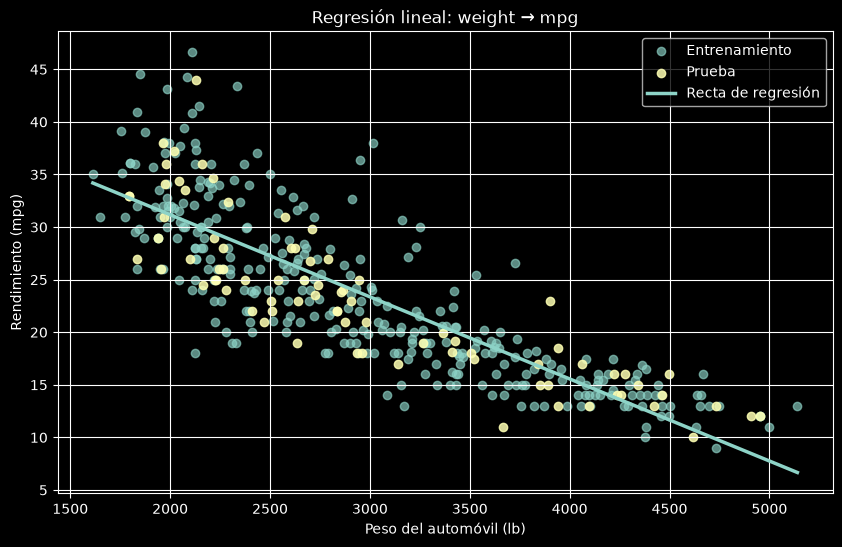

In [22]:
weight_line = np.linspace(
    selected_data["weight"].min(),
    selected_data["weight"].max(),
    100,
)

weight_line_df = pd.DataFrame({
    "weight": weight_line
})

mpg_line = model.predict(
    weight_line_df
)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train["weight"],
    y_train,
    alpha=0.65,
    label="Entrenamiento",
)

plt.scatter(
    X_test["weight"],
    y_test,
    alpha=0.85,
    label="Prueba",
)

plt.plot(
    weight_line,
    mpg_line,
    linewidth=2.5,
    label="Recta de regresión",
)

plt.xlabel("Peso del automóvil (lb)")
plt.ylabel("Rendimiento (mpg)")
plt.title("Regresión lineal: weight → mpg")
plt.legend()
plt.grid(True)
plt.show()

# 9. Evaluación

Las métricas utilizadas serán:

### Error absoluto medio

$$
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
\left|y_i-\hat{y}_i\right|
$$

### Error cuadrático medio

$$
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
\left(y_i-\hat{y}_i\right)^2
$$

### Raíz del error cuadrático medio

$$
RMSE=
\sqrt{MSE}
$$

### Coeficiente de determinación

$$
R^2=
1-
\frac{
\sum_{i=1}^{n}
\left(y_i-\hat{y}*i\right)^2
}{
\sum*{i=1}^{n}
\left(y_i-\bar{y}\right)^2
}
$$

El MAE y el RMSE se expresan en las mismas unidades que la variable objetivo, en este caso, millas por galón.

El coeficiente $R^2$ indica qué proporción de la variación de los datos puede explicar el modelo.


### Código explicado: Cálculo de métricas

Las métricas se calculan únicamente con los datos de prueba.

#### Código que se ejecutará

```python
mae = mean_absolute_error(
    y_test,
    y_pred,
)

mse = mean_squared_error(
    y_test,
    y_pred,
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred,
)

print(f"MAE:  {mae:.4f} mpg")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f} mpg")
print(f"R²:   {r2:.4f}")
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [23]:
mae = mean_absolute_error(
    y_test,
    y_pred,
)

mse = mean_squared_error(
    y_test,
    y_pred,
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred,
)

print(f"MAE:  {mae:.4f} mpg")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f} mpg")
print(f"R²:   {r2:.4f}")

MAE:  3.1178 mpg
MSE:  14.8949
RMSE: 3.8594 mpg
R²:   0.7230


# 10. Predicción de un automóvil nuevo

### Código explicado: Automóvil de 3000 libras

Se crea un DataFrame con la misma columna del entrenamiento y se solicita una
estimación.

#### Código que se ejecutará

```python
new_car = pd.DataFrame({
    "weight": [
        3000,
    ]
})

predicted_mpg = model.predict(
    new_car
)[0]

print("Peso: 3000 lb")
print(
    f"Rendimiento estimado: "
    f"{predicted_mpg:.2f} mpg"
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [24]:
new_car = pd.DataFrame({
    "weight": [
        3000,
    ]
})

predicted_mpg = model.predict(
    new_car
)[0]

print("Peso: 3000 lb")
print(
    f"Rendimiento estimado: "
    f"{predicted_mpg:.2f} mpg"
)

Peso: 3000 lb
Rendimiento estimado: 23.37 mpg


Una predicción dentro del rango observado es una **interpolación**. Una
predicción fuera del rango es una **extrapolación** y puede ser menos confiable.

# 11. Análisis de residuos

### Código explicado: Gráfica de residuos

Los residuos deberían distribuirse alrededor de cero sin una forma demasiado
marcada.

#### Código que se ejecutará

```python
residuals = (
    y_test
    - y_pred
)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.8,
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Rendimiento predicho (mpg)")
plt.ylabel("Residuo: real - predicho")
plt.title("Análisis de residuos")
plt.grid(True)
plt.show()
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

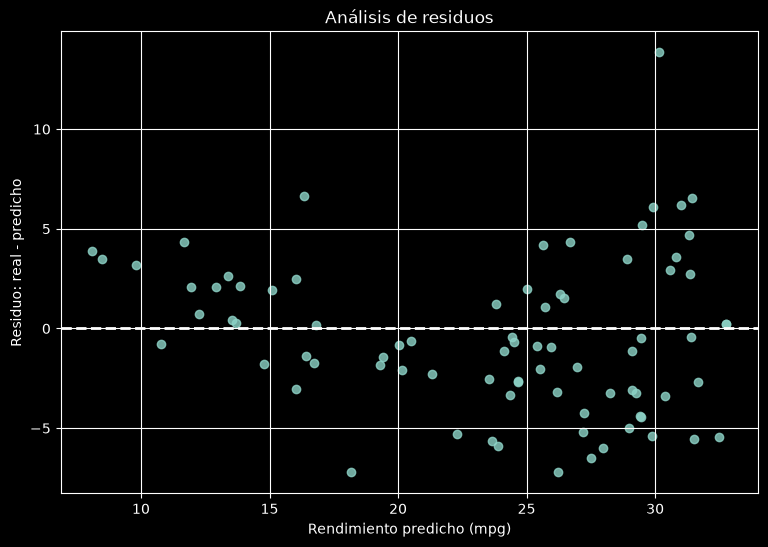

In [25]:
residuals = (
    y_test
    - y_pred
)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.8,
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Rendimiento predicho (mpg)")
plt.ylabel("Residuo: real - predicho")
plt.title("Análisis de residuos")
plt.grid(True)
plt.show()

### Código explicado: Comprobación manual de la ecuación

La predicción manual con \(mx+b\) debe coincidir con `model.predict()`.

#### Código que se ejecutará

```python
example_weight = 3000

manual_prediction = (
    slope * example_weight
    + intercept
)

sklearn_prediction = model.predict(
    pd.DataFrame({
        "weight": [
            example_weight,
        ]
    })
)[0]

print(
    "Predicción manual:",
    manual_prediction,
)

print(
    "Predicción Scikit-learn:",
    sklearn_prediction,
)

print(
    "Diferencia:",
    abs(
        manual_prediction
        - sklearn_prediction
    ),
)
```

> La siguiente celda contiene el mismo código completo y puede ejecutarse directamente.

In [26]:
example_weight = 3000

manual_prediction = (
    slope * example_weight
    + intercept
)

sklearn_prediction = model.predict(
    pd.DataFrame({
        "weight": [
            example_weight,
        ]
    })
)[0]

print(
    "Predicción manual:",
    manual_prediction,
)

print(
    "Predicción Scikit-learn:",
    sklearn_prediction,
)

print(
    "Diferencia:",
    abs(
        manual_prediction
        - sklearn_prediction
    ),
)

Predicción manual: 23.366336311665837
Predicción Scikit-learn: 23.366336311665837
Diferencia: 0.0


# 12. Conclusiones

El flujo realizado fue:

```text
Descargar datos
      ↓
Explorar variables
      ↓
Seleccionar X e y
      ↓
Dividir entrenamiento y prueba
      ↓
Entrenar LinearRegression
      ↓
Predecir
      ↓
Evaluar
      ↓
Analizar residuos
```

El peso permite explicar una parte importante del rendimiento, pero no toda.
También influyen cilindros, potencia, desplazamiento, año y otras variables.

# 13. Actividades

1. Predice el rendimiento para 2500 y 4000 libras.
2. Cambia `test_size` a 0.30.
3. Cambia `random_state`.
4. Sustituye `weight` por `displacement`.
5. Convierte libras a kilogramos y analiza la nueva pendiente.
6. Explica por qué `horsepower` requiere limpieza.
7. Identifica si existen valores con residuos especialmente grandes.

## 14. Continuación

Esta misma base puede utilizarse para:

```text
01. Regresión lineal simple
02. Regresión lineal múltiple
03. Imputación de horsepower
04. Regresión polinomial
05. Árbol de regresión
06. Random Forest
```

En regresión múltiple se utilizará:

$$\hat{y}=b+m_1x_1+m_2x_2+\cdots+m_px_p$$



# Referencias

- UCI Machine Learning Repository: Auto MPG.
- Scikit-learn: `LinearRegression`.
- Scikit-learn: métricas de regresión.